In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Exercice 1

### Parameters

In [2]:
S0 = 100 # g/L
CL0 = 6 # mg/L
P0 = 0 # g/L

k = 3.2e-13 # coefficient
N0 = 30000 # h^-1
CL_star = 6 # mg/L

Vm0 = 16 # g/L/h
Ks = 7 # g/L
KCL = 0.3 # mg/L

YOS = 5 # mg O2 / g substrate
YPS = 1.5 # g product / g substrate

oxygen_limit_threshold = 3 * KCL

### Model fonctions

In [3]:
def kLa(N, G):
    return k * N**3 * np.sqrt(G)


def reaction_rate(S, CL, Vm):
    return Vm * S / (Ks + S) * CL / (KCL + CL)


def ode_system(t, y, Vm, N, G):
    S, CL, P = y

    # avoid negative values
    S = max(S, 0)
    CL = max(CL, 0)

    rs = reaction_rate(S, CL, Vm)
    kla = kLa(N, G)

    dSdt = -rs
    dCLdt = kla * (CL_star - CL) - YOS * rs
    dPdt = YPS * rs

    return [dSdt, dCLdt, dPdt]


def simulate(Vm=Vm0, N=N0, G=30.0, t_end=80):
    y0 = [S0, CL0, P0]
    t_eval = np.linspace(0, t_end, 1000)

    sol = solve_ivp(
        ode_system,
        [0, t_end],
        y0,
        args=(Vm, N, G),
        method="BDF",
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    return sol


def find_steady_start(sol, tol=1e-3):
    """
    Approximate beginning of steady state as the first time where |dS/dt| < tol.
    """
    S = sol.y[0]
    dSdt = np.gradient(S, sol.t)

    for i in range(len(sol.t)):
        if abs(dSdt[i]) < tol and S[i] < 1e-2:
            return sol.t[i]

    return sol.t[-1]

### a) Simulating the model 

Part a:
kLa = 47.32322896844636 h^-1
Minimum CL = 4.521006678170532 mg/L
Oxygen limited? False


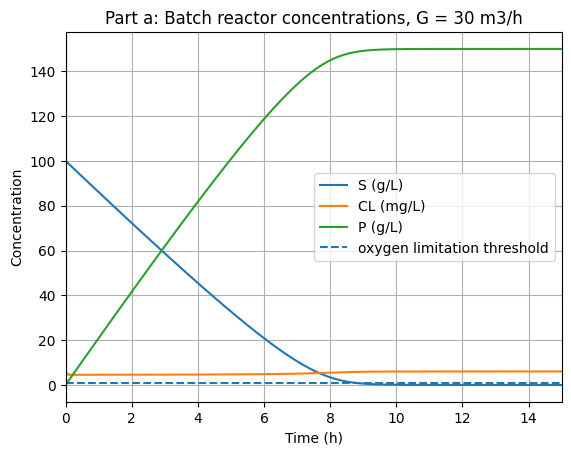

In [4]:
G_a = 30
sol_a = simulate(Vm0, N0, G_a)

S_a, CL_a, P_a = sol_a.y
print("Part a:")
print("kLa =", kLa(N0, G_a), "h^-1")
print("Minimum CL =", np.min(CL_a), "mg/L")
print("Oxygen limited?", np.min(CL_a) <= oxygen_limit_threshold)

plt.figure()
plt.plot(sol_a.t, S_a, label="S (g/L)")
plt.plot(sol_a.t, CL_a, label="CL (mg/L)")
plt.plot(sol_a.t, P_a, label="P (g/L)")
plt.axhline(oxygen_limit_threshold, linestyle="--", label="oxygen limitation threshold")
plt.xlabel("Time (h)")
plt.ylabel("Concentration")
plt.title("Part a: Batch reactor concentrations, G = 30 m3/h")
plt.xlim(0, 15)
plt.legend()
plt.grid(True)
plt.show()

### b) Aeration rate 


Part b:
Approximate critical G = 1.6089175772366866 m3/h


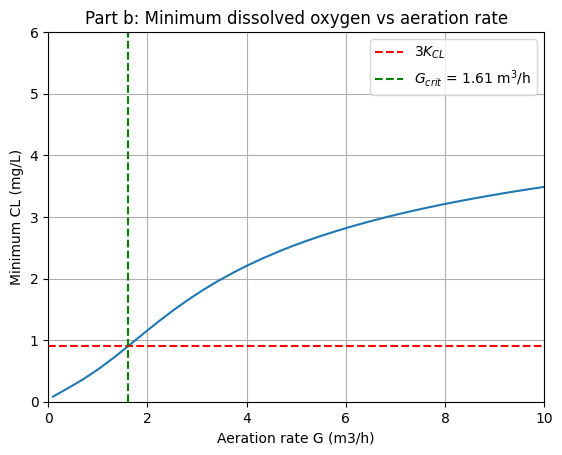

In [5]:
G_values = np.linspace(0.1, 30, 100)
CL_min_values = []

for G in G_values:
    sol = simulate(Vm0, N0, G)
    CL_min_values.append(np.min(sol.y[1]))

CL_min_values = np.array(CL_min_values)

# find G where CL_min crosses the oxygen limitation threshold
G_lim = np.interp(oxygen_limit_threshold, CL_min_values, G_values)

print("\nPart b:")
print("Approximate critical G =", G_lim, "m3/h")

plt.figure()
plt.plot(G_values, CL_min_values)
plt.axhline(oxygen_limit_threshold, color='red', linestyle='--', label=r"$3K_{CL}$")

plt.axvline(G_lim, color="green", linestyle="--", label=fr"$G_{{crit}}$ = {G_lim:.2f} m$^3$/h")
plt.xlabel("Aeration rate G (m3/h)")
plt.ylabel("Minimum CL (mg/L)")
plt.title("Part b: Minimum dissolved oxygen vs aeration rate")
plt.legend()
plt.xlim(0, 10)
plt.ylim(0, 6)
plt.grid(True)
plt.show()

### c-d) Modify aeration rate


Part c:
Full Vm average product rate = 10.890214761564772 g/L/h
Half Vm average product rate = 6.14133709741501 g/L/h
Ratio half/full = 0.5639316792070853
Full Vm oxygen limited? True
Half Vm oxygen limited? False


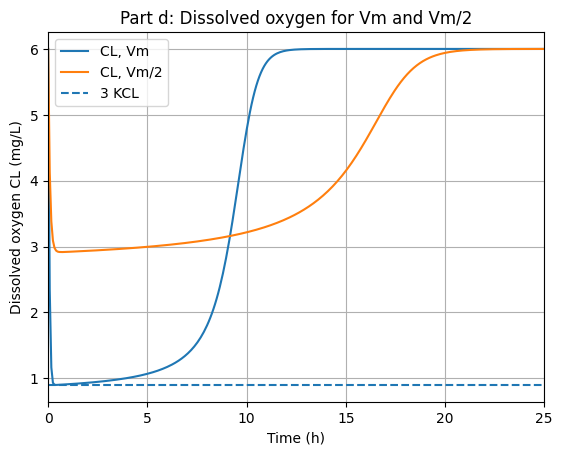

In [6]:
G_c = G_lim

sol_full = simulate(Vm0, N0, G_c)
sol_half = simulate(Vm0 / 2, N0, G_c)

def average_product_rate(sol):
    t_ss = find_steady_start(sol)
    P_ss = np.interp(t_ss, sol.t, sol.y[2])
    return P_ss / t_ss, t_ss

rate_full, tss_full = average_product_rate(sol_full)
rate_half, tss_half = average_product_rate(sol_half)

print("\nPart c:")
print("Full Vm average product rate =", rate_full, "g/L/h")
print("Half Vm average product rate =", rate_half, "g/L/h")
print("Ratio half/full =", rate_half / rate_full)
print("Full Vm oxygen limited?", np.min(sol_full.y[1]) <= oxygen_limit_threshold)
print("Half Vm oxygen limited?", np.min(sol_half.y[1]) <= oxygen_limit_threshold)

plt.figure()
plt.plot(sol_full.t, sol_full.y[1], label="CL, Vm")
plt.plot(sol_half.t, sol_half.y[1], label="CL, Vm/2")
plt.axhline(oxygen_limit_threshold, linestyle="--", label="3 KCL")
plt.xlabel("Time (h)")
plt.ylabel("Dissolved oxygen CL (mg/L)")
plt.title("Part d: Dissolved oxygen for Vm and Vm/2")
plt.legend()
plt.xlim(0, 25)
plt.grid(True)
plt.show()

### e) Oxygen-limited conditions


Part e:
Original kLa = 10.959245118788418
Reduced N kLa = 6.7303464085759375
kLa ratio = 0.614125
Minimum CL reduced N = 0.3156972604390512
Oxygen limited reduced N? True


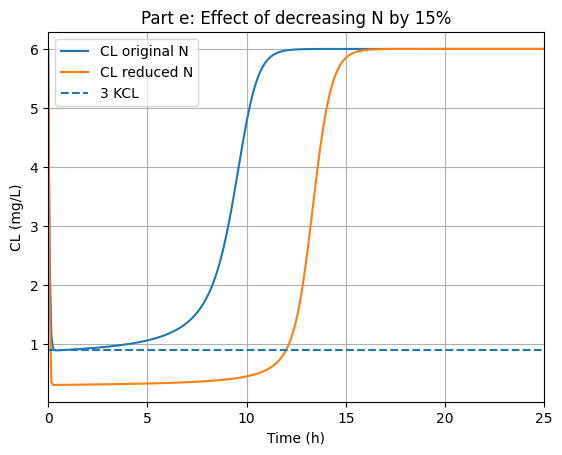

In [7]:
N_reduced = 0.85 * N0
sol_e = simulate(Vm0, N_reduced, G_c)

print("\nPart e:")
print("Original kLa =", kLa(N0, G_c))
print("Reduced N kLa =", kLa(N_reduced, G_c))
print("kLa ratio =", kLa(N_reduced, G_c) / kLa(N0, G_c))
print("Minimum CL reduced N =", np.min(sol_e.y[1]))
print("Oxygen limited reduced N?", np.min(sol_e.y[1]) <= oxygen_limit_threshold)

plt.figure()
plt.plot(sol_full.t, sol_full.y[1], label="CL original N")
plt.plot(sol_e.t, sol_e.y[1], label="CL reduced N")
plt.axhline(oxygen_limit_threshold, linestyle="--", label="3 KCL")
plt.xlabel("Time (h)")
plt.ylabel("CL (mg/L)")
plt.title("Part e: Effect of decreasing N by 15%")
plt.legend()
plt.xlim(0, 25)
plt.grid(True)
plt.show()

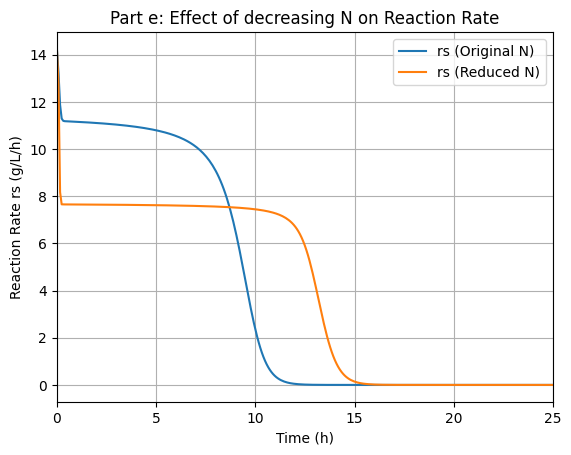

In [8]:
# see the effect on reaction rate rs
rs_original = reaction_rate(sol_full.y[0], sol_full.y[1], Vm0)
rs_reduced = reaction_rate(sol_e.y[0], sol_e.y[1], Vm0)

plt.figure()
plt.plot(sol_full.t, rs_original, label="rs (Original N)")
plt.plot(sol_e.t, rs_reduced, label="rs (Reduced N)")
plt.xlabel("Time (h)")
plt.ylabel("Reaction Rate rs (g/L/h)")
plt.title("Part e: Effect of decreasing N on Reaction Rate")
plt.legend()
plt.xlim(0, 25)
plt.grid(True)
plt.show()

In [9]:
# Get the rs where the CL is minimum (peak limitation)
idx_min_full = np.argmin(sol_full.y[1])
idx_min_reduced = np.argmin(sol_e.y[1])

rs_min_full = rs_original[idx_min_full]
rs_min_reduced = rs_reduced[idx_min_reduced]

print(f"Peak limitation rs (Original N) = {rs_min_full:.2f} g/L/h")
print(f"Peak limitation rs (Reduced N) = {rs_min_reduced:.2f} g/L/h")

Peak limitation rs (Original N) = 11.18 g/L/h
Peak limitation rs (Reduced N) = 7.65 g/L/h


### f) Variation of N and G

Part f:
N=30000, G=30.0, kLa=47.32, min CL=4.521, non-limited=True
N=35000, G=20.0, kLa=61.36, min CL=4.854, non-limited=True
N=40000, G=10.0, kLa=64.76, min CL=4.913, non-limited=True
N=45000, G=5.0, kLa=65.20, min CL=4.921, non-limited=True
N=50000, G=3.0, kLa=69.28, min CL=4.984, non-limited=True


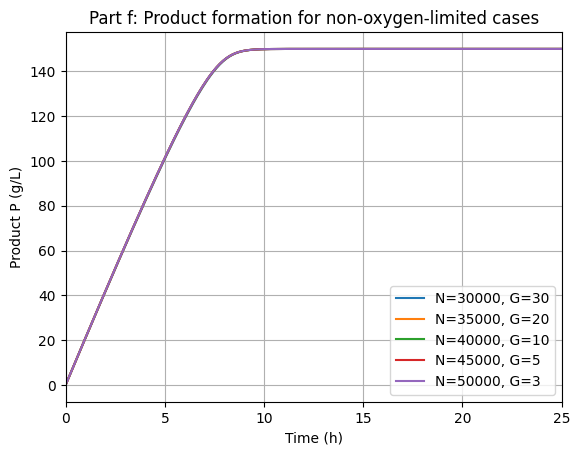

In [10]:
combinations = [
    (30000, 30),
    (35000, 20),
    (40000, 10),
    (45000, 5),
    (50000, 3),
]

plt.figure()

print("Part f:")
for N, G in combinations:
    sol = simulate(Vm0, N, G)
    min_CL = np.min(sol.y[1])
    print(f"N={N:.0f}, G={G:.1f}, kLa={kLa(N,G):.2f}, min CL={min_CL:.3f}, non-limited={min_CL > oxygen_limit_threshold}")
    plt.plot(sol.t, sol.y[2], label=f"N={N:.0f}, G={G}")

plt.xlabel("Time (h)")
plt.ylabel("Product P (g/L)")
plt.title("Part f: Product formation for non-oxygen-limited cases")
plt.legend()
plt.xlim(0, 25)
plt.grid(True)
plt.show()